In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [9]:
# Выводим информацию о типах данных в каждом столбце и наличии пропусков
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [10]:
# Переводим столбец 'Дата' в тип данных datetime
df['Дата'] = pd.to_datetime(df['Дата'])

print(df['Дата'].dtype)

datetime64[ns]


Сгруппируйте данные по дате, посчитайте количество продаж

In [11]:
# Группируем по столбцу 'Дата' и суммируем столбец 'Количество'
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [12]:
# Выводим первые 5 строк полученного датафрейма grouped_df
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

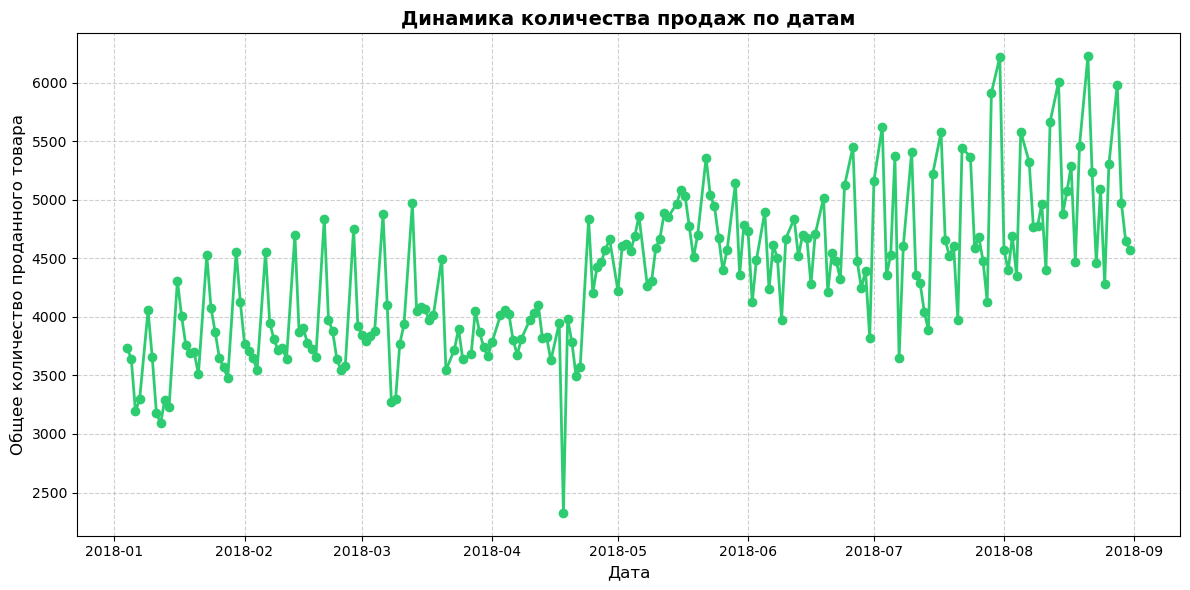

In [13]:
import matplotlib.pyplot as plt

# Настраиваем размер графика
plt.figure(figsize=(12, 6))

# Строим линейный график, где по оси X — Дата, по оси Y — Количество
plt.plot(grouped_df['Дата'], grouped_df['Количество'], color='#2ecc71', marker='o', linewidth=2)

# Добавляем заголовки и сетку
plt.title('Динамика количества продаж по датам', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Общее количество проданного товара', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Автоматически выравниваем элементы и показываем график
plt.tight_layout()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [14]:
# На графике представлена динамика продаж за период с января по сентябрь 2018 года. 
#Основной тренд: Продажи на протяжении всего рассматриваемого периода находятся на стабильно низком уровне, совершая незначительные колебания около околонулевой отметки.
#Аномалия (Выброс): На графике четко фиксируется аномальный всплеск (выброс) в районе конца апреля — начала мая 2018 года. 
#В этот день объём продаж резко возрастает, достигая своего пика, после чего мгновенно возвращается к прежним фоновым значениям. 
#Это может быть связано с крупным оптовым заказом, техническим сбоем или успешной краткосрочной акцией.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [15]:
# Находим индекс строки с максимальным значением в столбце 'Количество'
max_sales_index = df['Количество'].idxmax()

# Выводим всю строку с этим выбросом
max_sales_row = df.loc[[max_sales_index]]
max_sales_row

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [16]:
# 1. Фильтруем данные: июнь(6), июль(7), август(8), Склад == 3
summer_df = df[
    (df['Дата'].dt.month.isin([6, 7, 8])) & 
    (df['Склад'] == 3)
].copy()

# 2. Добавляем фильтр по дням недели: среда (в pandas dt.dayofweek == 2, где 0-понедельник)
wednesdays_summer_df = summer_df[summer_df['Дата'].dt.dayofweek == 2]

# 3. Группируем по номенклатуре, считаем сумму продаж и берем лидера
top_product = wednesdays_summer_df.groupby('Номенклатура')['Количество'].sum().reset_index()
top_product = top_product.sort_values(by='Количество', ascending=False)

# Выводим самый продаваемый товар
print("Топовый товар по средам за лето у 3 склада:")
print(top_product.head(1))

Топовый товар по средам за лето у 3 склада:
  Номенклатура  Количество
1    product_1        2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

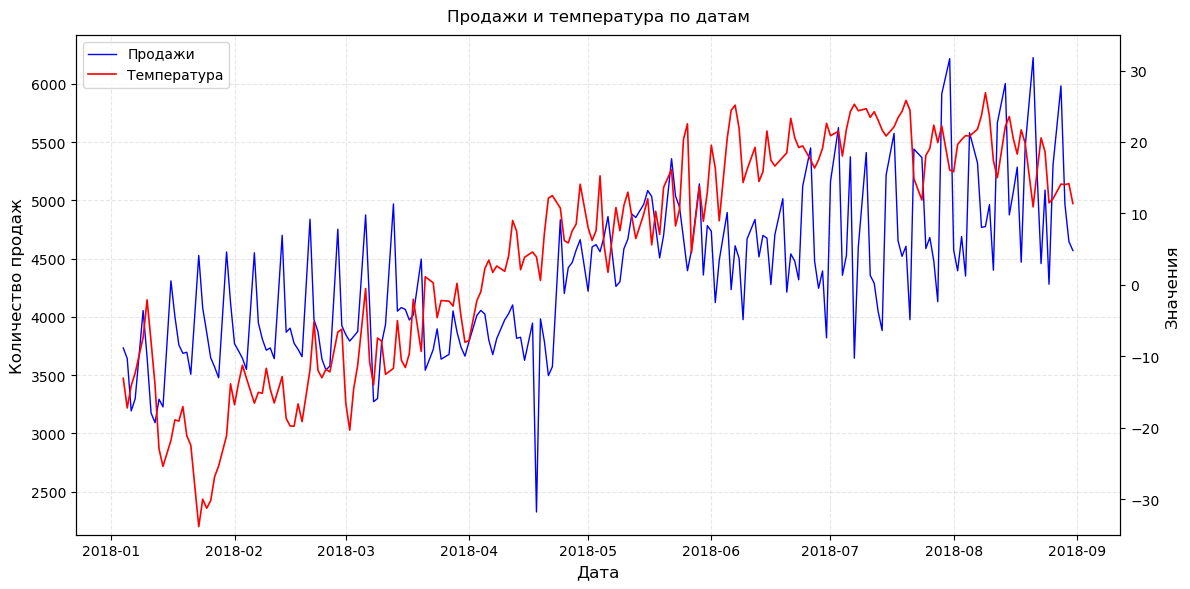

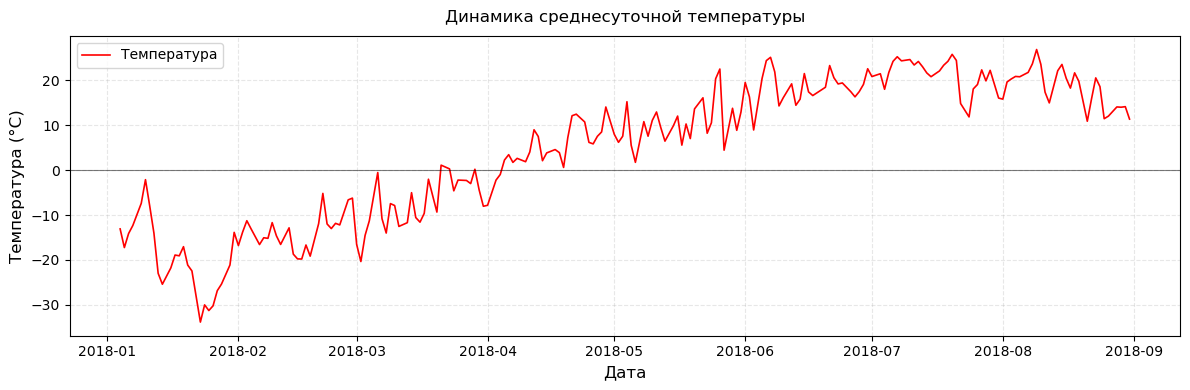

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 0. ВОССТАНОВЛЕНИЕ ОПЕРАЦИЙ С ПРОДАЖАМИ
# ==========================================
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата'])

# ==========================================
# 1. ЗАГРУЗКА И ОЧИСТКА ДАННЫХ О ПОГОДЕ
# ==========================================
weather_df = pd.read_csv('weather.csv', sep=';') 

time_col = weather_df.columns[0]
weather_df[time_col] = pd.to_datetime(weather_df[time_col], dayfirst=True)
weather_df['Дата'] = weather_df[time_col].dt.date

weather_df['T'] = weather_df['T'].astype(str).str.replace(',', '.')
weather_df['T'] = pd.to_numeric(weather_df['T'], errors='coerce')
weather_df = weather_df.dropna(subset=['T'])

daily_weather = weather_df.groupby('Дата')['T'].mean().reset_index()
daily_weather['Дата'] = pd.to_datetime(daily_weather['Дата'])

# ==========================================
# 2. ОБЪЕДИНЕНИЕ ТАБЛИЦ
# ==========================================
merged_df = pd.merge(grouped_df, daily_weather, on='Дата', how='inner')

# ==========================================
# 3. ПОСТРОЕНИЕ ИТОГОВОГО ГРАФИКА
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Левая ось: Продажи (синяя линия)
color_sales = 'blue'
ax1.set_ylabel('Количество продаж', color='black', fontsize=12)
line1 = ax1.plot(merged_df['Дата'], merged_df['Количество'], color=color_sales, linewidth=1, label='Продажи')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, linestyle='--', alpha=0.3)

# Правая ось: Температура (красная линия)
ax2 = ax1.twinx()  
color_temp = 'red'
ax2.set_ylabel('Значения', color='black', fontsize=12) # Сделали подпись строго как на образце
line2 = ax2.plot(merged_df['Дата'], merged_df['T'], color=color_temp, linewidth=1.2, label='Температура')
ax2.tick_params(axis='y', labelcolor='black')

# ЕСЛИ ХОТИТЕ ЖЕСТКО СТАТЬ КАК В ОБРАЗЦЕ (от 1200 до 1800), раскомментируйте строку ниже:
# ax1.set_ylim(1150, 1850)
ax2.set_ylim(-35, 35)

# ХИТРЫЙ ШАГ: Исправление легенды, чтобы внутри рамки были обе линии
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)

plt.title('Продажи и температура по датам', fontsize=12, pad=10)
ax1.set_xlabel('Дата', fontsize=12)

fig.tight_layout()
plt.show()

# ==========================================
# 4. ОТДЕЛЬНЫЙ ГРАФИК ТЕМПЕРАТУРЫ (по заданию)
# ==========================================
plt.figure(figsize=(12, 4))
plt.plot(merged_df['Дата'], merged_df['T'], color='red', linewidth=1.2, label='Температура')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.5)

plt.title('Динамика среднесуточной температуры', fontsize=12, pad=10)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()